In [1]:
import networkx as nx
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt
import random
from collections import Counter

## Question 1

In [2]:
G0 = nx.watts_strogatz_graph(1000,10,0)

In [8]:
def Get_C(G):
    """
    For each node v:
    Number of edges between its neighbors / Maximum possible number of edges between its neighbors
    Then take the average over all nodes.
    """
    Cv = []
    for v in G.nodes():
        neighbors = list(G.neighbors(v))
        k = len(neighbors)
        if k < 2:
            Cv.append(0.0)
            continue
        actual_edges = 0
        for u, w in combinations(neighbors, 2):
            if G.has_edge(u, w):
                actual_edges += 1
        possible_edges = (k*(k - 1))/2
        Cv.append(actual_edges / possible_edges)

    return np.mean(Cv)

def Get_L(G):
    """
    Calculate the average shortest path within the largest connected component.
    """
    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc)

    return nx.average_shortest_path_length(G)

In [9]:
C0 = Get_C(G0)
L0 = Get_L(G0)

In [10]:
p_list = np.logspace(-4, 0, 14)

In [11]:
C_data = []
L_data = []
for p in p_list:
    G_temp = nx.watts_strogatz_graph(1000,10,p)
    C = Get_C(G_temp)/ C0
    L = Get_L(G_temp)/ L0
    C_data.append(C)
    L_data.append(L)

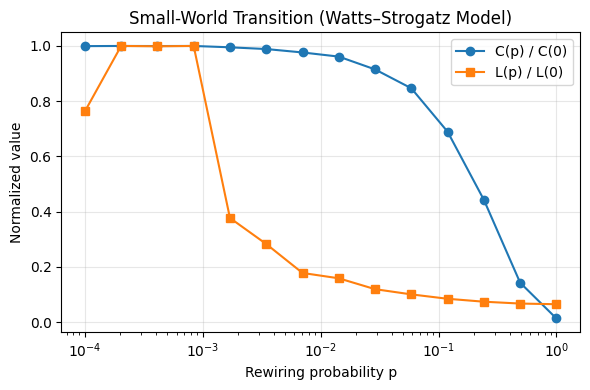

<Figure size 640x480 with 0 Axes>

In [12]:
plt.figure(figsize=(6,4))

plt.plot(p_list, C_data, 'o-', label='C(p) / C(0)')
plt.plot(p_list, L_data, 's-', label='L(p) / L(0)')

plt.xscale('log')
plt.xlabel('Rewiring probability p')
plt.ylabel('Normalized value')
plt.legend()
plt.grid(alpha=0.3)

plt.title('Small-World Transition (Watts–Strogatz Model)')
plt.tight_layout()
plt.show()
plt.savefig("small_world_transition.pdf",format="pdf")

When a shortcut appears, its impact on the overall C value is not significant, but for L, a shortcut affects many nearby nodes. This causes the average shortest path to change significantly even at very small p values. Even with multiple iterations, the impact of the appearance of shortcuts remains substantial.
__________

## Question 2

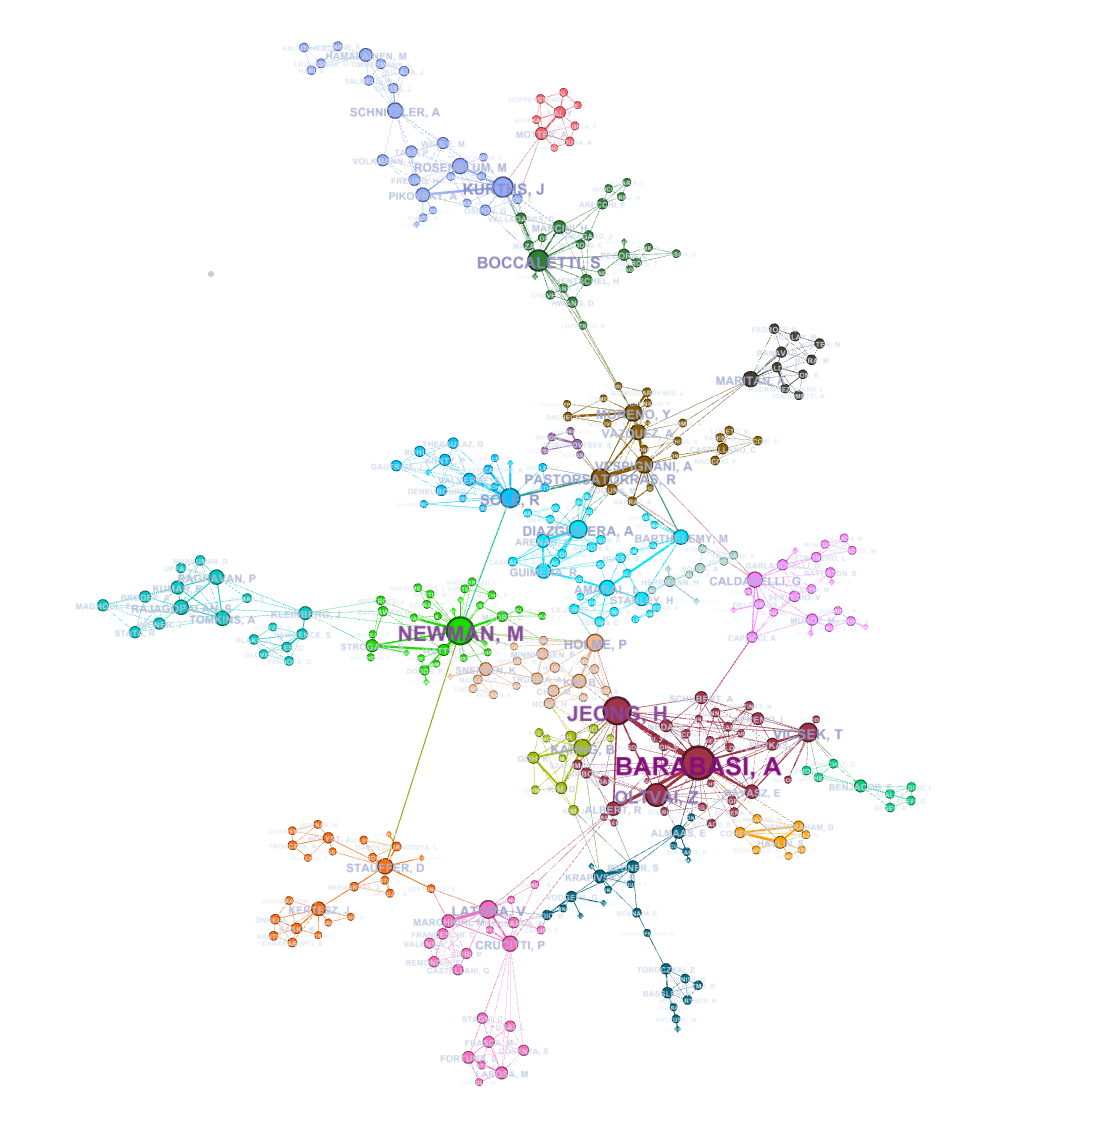

The size of each node reflects its degree value, and its color indicates which community it belongs to. The font size also reflects the degree distribution; lighter colors indicate less important nodes (smaller degrees). This graph exhibits scale-free properties. A small number of nodes have hub characteristics.In contrast, the majority of nodes have low degrees and are located at the periphery of communities, contributing mainly to local cohesion rather than global connectivity.This characteristic suggests that scientists prefer to collaborate with well-known scientists.
__________

## Question 3

In [24]:
def Gen_ba_graph(n:int, m: int= 4, m0: int= 4, seed: int= 0, snapshot_list =[100,1000,10000], tracking = False, track_nodes = None):
    """
    Generate a Barabási–Albert (BA) network

    Parameters
    ----------
    n : int
        Total number of nodes in the final network.
    m : int
        Number of edges each new node introduces (must satisfy 1 <= m <= m0).
    m0 : int
        Number of nodes in the initial fully connected seed graph.
    seed : int
        Random seed for reproducibility.
    snapshot_list : list of int
        Network sizes at which full graph snapshots are recorded.
    tracking : bool
        If True, track degree evolution of specified nodes over time.
    track_nodes : list or iterable
        Node indices whose degree dynamics are tracked. Required if tracking=True.

    Returns
    -------
    snapshots : dict
        Dictionary mapping network size N to a copy of the graph at that size.
    degree_history : dict, optional
        Returned only if tracking=True. A dictionary mapping node IDs to their
        degree time series, with keys {"t", "k"} representing time and degree.
    """
    rng = random.Random(seed)
    G = nx.complete_graph(m0)
    
    snapshots = {}
    degrees = []
    degree_history = None
    
    for u in G.nodes():
        degrees.extend([u] * G.degree(u))

    if tracking:
        degree_history = {u: {"t": [], "k": []} for u in track_nodes}
        
    for new_node in range(m0, n):
        G.add_node(new_node)

        targets = set()
        while len(targets) < m:
            targets.add(rng.choice(degrees))

        for v in targets:
            G.add_edge(new_node, v)

        degrees.extend([new_node] * m)
        degrees.extend(list(targets))

        cur_n = new_node + 1
        if cur_n in snapshot_list:
            snapshots[cur_n] = G.copy()
        if tracking:
            for u in track_nodes:
                if u <= new_node and u in G:
                    degree_history[u]["t"].append(cur_n)
                    degree_history[u]["k"].append(G.degree(u))
        if len(snapshots) == len(snapshot_list) and cur_n >= max(snapshot_list):
            break

    return (snapshots, degree_history) if tracking else snapshots


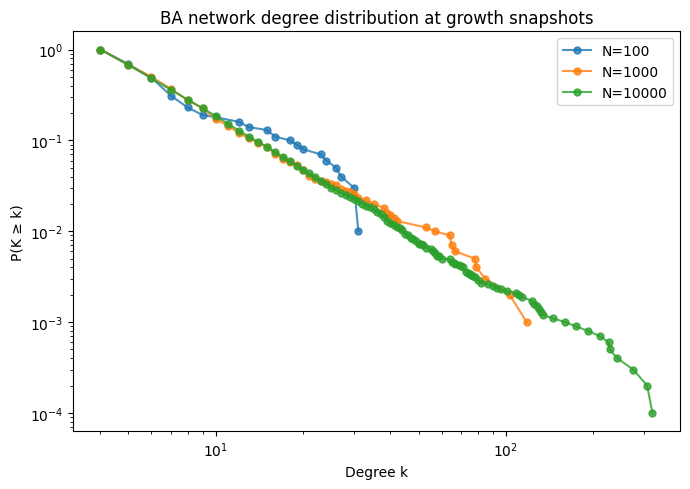

In [25]:
def degree_ccdf(G):
    """
    Return (k_sorted, ccdf) where ccdf[k] = P(K >= k).
    """
    degrees = np.array([d for _, d in G.degree()], dtype=int)
    k_vals = np.sort(np.unique(degrees))
    ccdf = np.array([(degrees >= k).mean() for k in k_vals], dtype=float)
    return k_vals, ccdf
snapshot = [100,1000,10000]
snaps = Gen_ba_graph(10000,snapshot_list = snapshot)

plt.figure(figsize=(7, 5))
for N in snapshot:
    Gs = snaps[N]
    k, ccdf = degree_ccdf(Gs)
    plt.loglog(k, ccdf, "o-", ms = 5, label=f"N={N}",alpha = 0.8)

plt.xlabel("Degree k")
plt.ylabel("P(K ≥ k)")
plt.title("BA network degree distribution at growth snapshots")
plt.legend()
plt.tight_layout()
plt.show()

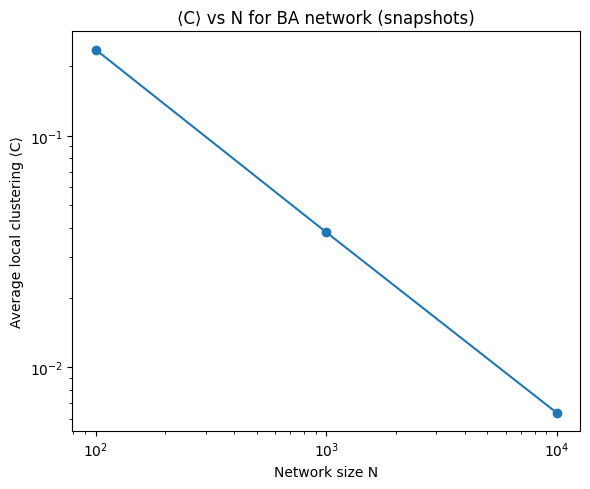

In [11]:
def compute_clustering(snapshots: dict):
    """
    Compute average local clustering coefficient <C> for each snapshot size N.
    Returns sorted arrays (N_vals, C_vals).
    """
    Ns = sorted(snapshots.keys())
    C_avgs = [nx.average_clustering(snapshots[N]) for N in Ns]
    return np.array(Ns), np.array(C_avgs)
    
N_vals, C_vals = compute_clustering(snaps)

plt.figure(figsize=(6, 5))
plt.loglog(N_vals, C_vals, marker='o', linestyle='-')
plt.xlabel("Network size N")
plt.ylabel("Average local clustering ⟨C⟩")
plt.title("⟨C⟩ vs N for BA network (snapshots)")
plt.tight_layout()
plt.show()

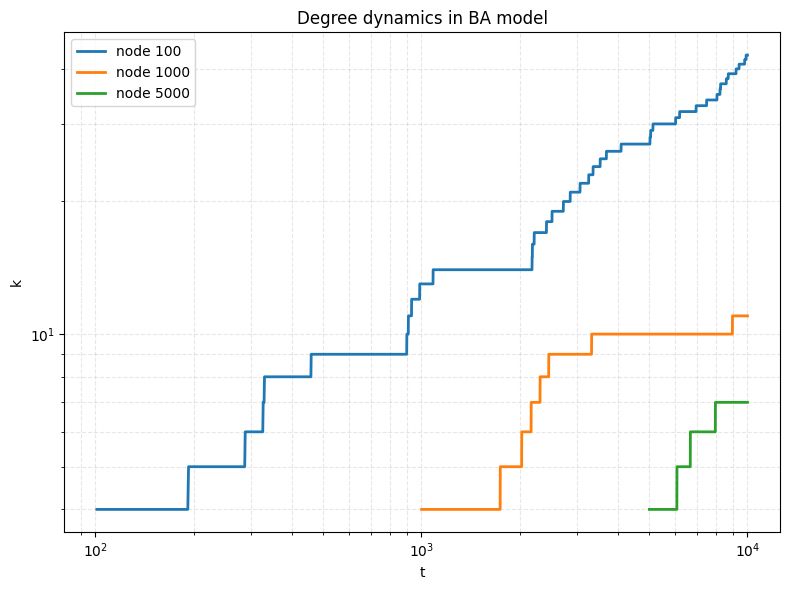

In [30]:
snapshots, degree_history = Gen_ba_graph(n=10000, m=4, m0=4,seed= 4, tracking=True, track_nodes=[100, 1000, 5000])

plt.figure(figsize=(8,6))
for node, data in degree_history.items():
    t = np.array(data["t"])
    k = np.array(data["k"])
    plt.loglog(t, k, lw=2, label=f"node {node}")
plt.xlabel("t")
plt.ylabel("k")
plt.title("Degree dynamics in BA model")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.show()

### Part II

In [32]:
def gen_optimization_model(n: int, delta_list = [0.1, 10, 1000], seed: int = 0, center: int = 0, init_k: int = 4):
    """
    Optimization Model

    For each delta in delta_list, generate a graph where
    a new node i connects to node j minimizing:
        C_j = h_j + delta * d_ij

    Returns
    -------
    G_dict : dict
        {delta : nx.Graph}
    """
    G_dict = {}

    for delta in delta_list:
        rng = np.random.default_rng(seed)
        G = nx.Graph()

        pos = {i: (float(rng.random()), float(rng.random())) for i in range(init_k)}
        G.add_nodes_from(range(init_k))

        for u in range(init_k):
            for v in range(u + 1, init_k):
                G.add_edge(u, v)

        h = dict(nx.single_source_shortest_path_length(G, center))

        for new_node in range(init_k, n):
            xi, yi = float(rng.random()), float(rng.random())
            pos[new_node] = (xi, yi)
            G.add_node(new_node)

            best_j = None
            best_cost = None

            for j in G.nodes():
                if j == new_node:
                    continue
                xj, yj = pos[j]
                dij = ((xi - xj) ** 2 + (yi - yj) ** 2) ** 0.5
                hj = h[j]
                Cj = hj + delta * dij

                if (best_cost is None) or (Cj < best_cost):
                    best_cost = Cj
                    best_j = j

            G.add_edge(new_node, best_j)
            h = dict(nx.single_source_shortest_path_length(G, center))

        G_dict[delta] = G

    return G_dict


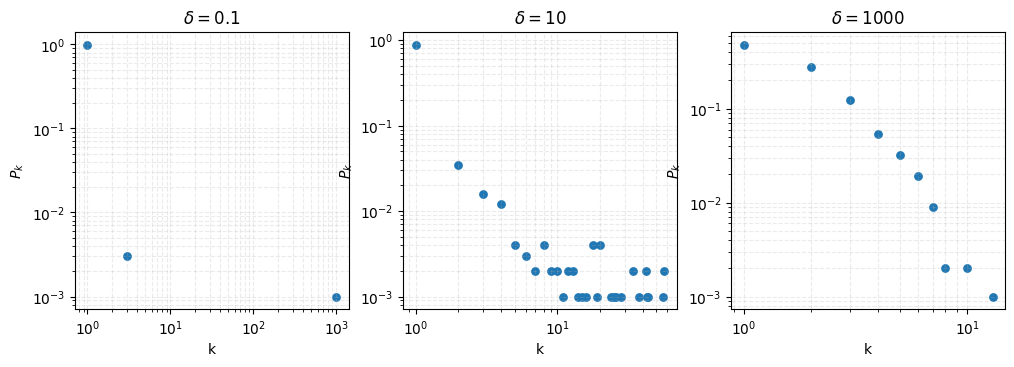

In [40]:
Gs = gen_optimization_model(n=1000, delta_list=[0.1, 10, 1000], seed=4)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=False)
for ax, delta in zip(axes, [0.1, 10, 1000]):
    G = Gs[delta]
    degs = np.array([d for _, d in G.degree()], dtype=int)
    N = len(degs)
    k, counts = np.unique(degs, return_counts=True)
    pk = counts / N
    ax.scatter(k, pk, s=28)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("k")
    ax.set_ylabel(r"$P_k$")
    ax.set_title(rf"$\delta={delta}$")

    ax.grid(True, which="both", ls="--", alpha=0.25)

/tmp/ipykernel_666/329821108.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


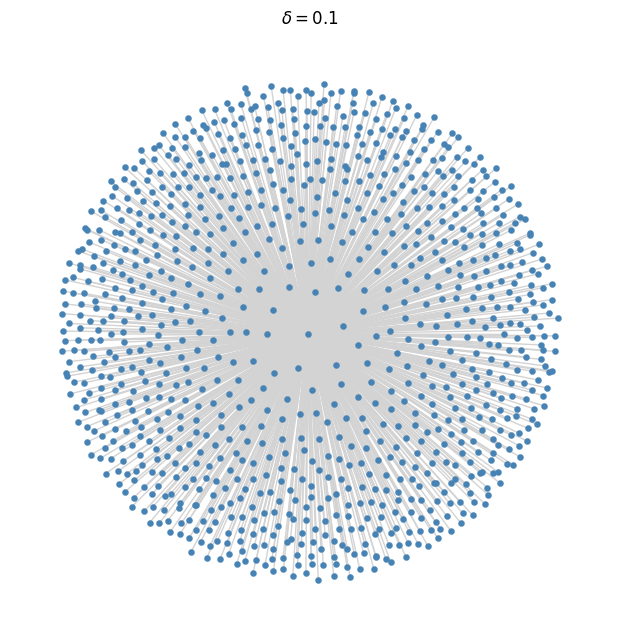

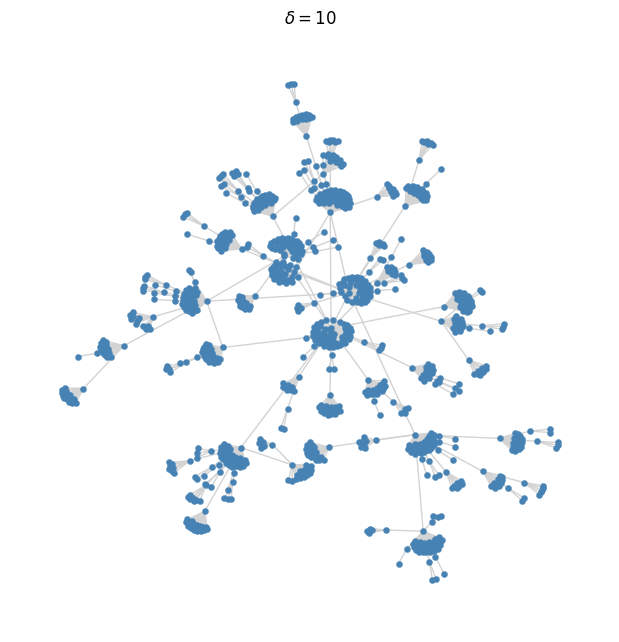

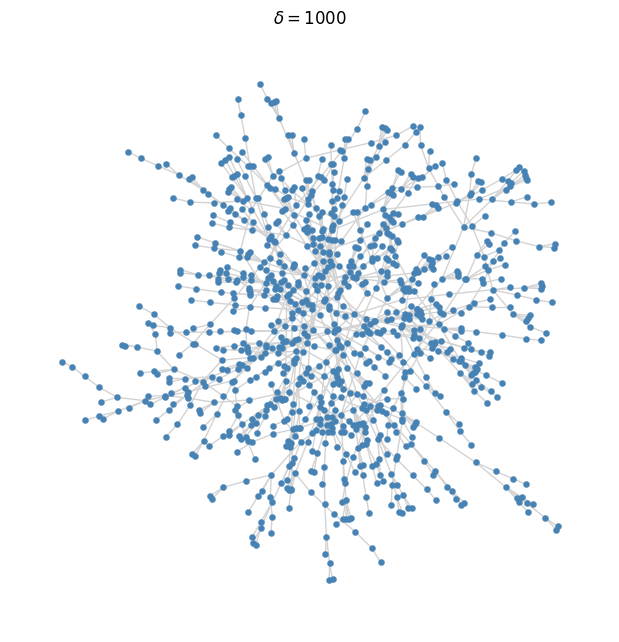

In [43]:
def plot_graph(G, title="", node_size=20):
    plt.figure(figsize=(6, 6))

    pos = nx.spring_layout(G, seed=0)
    nx.draw(
        G,
        pos,
        node_size=node_size,
        edge_color="lightgray",
        node_color="steelblue",
        linewidths=0.2
    )

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
plot_graph(Gs[0.1], title=r"$\delta=0.1$")
plot_graph(Gs[10],  title=r"$\delta=10$")
plot_graph(Gs[1000],title=r"$\delta=1000$")

In [16]:
def estimate_pi_kernel(G: nx.Graph, step_fn, state: dict, rng: np.random.Generator, trials: int = 5000):
    """
    Estimate Π(k) (attachment kernel) for a growing network model.

    For each growth step t:
      - compute current degree histogram n_t(k)
      - perform one step, which attaches to a target with degree k_target (before attachment)
      - accumulate:
            num[k_target] += 1
            den[k] += n_t(k)   for all k present at time t

    Then:
        Π(k) = num[k] / den[k]
    """
    num = defaultdict(float)
    den = defaultdict(float)

    for _ in range(trials):
        deg_hist = Counter(dict(G.degree()))
        for k, nk in deg_hist.items():
            den[int(k)] += float(nk)

        k_target = int(step_fn(G, rng, state))
        num[k_target] += 1.0

    k_vals = np.array(sorted(num.keys()), dtype=int)
    pi_k = np.array([num[k] / den[k] for k in k_vals], dtype=float)
    return k_vals, pi_k
    
def step_ba(G: nx.Graph, rng: np.random.Generator, state: dict):
    nodes = np.array(list(G.nodes()), dtype=int)
    degs = np.array([G.degree(v) for v in nodes], dtype=float)
    p = degs / degs.sum()

    target = int(rng.choice(nodes, p=p))
    k_target = G.degree(target)  # degree BEFORE attachment

    new_node = state["next_node"]
    state["next_node"] += 1

    G.add_node(new_node)
    G.add_edge(new_node, target)
    return k_target

def step_copying(G: nx.Graph, rng: np.random.Generator, state: dict):
    """
    Perform one growth step of the copying model.
    Parameters
    ----------
    G : nx.Graph
        Current network.
    rng : np.random.Generator
        Random number generator for reproducibility.
    state : dict
        Mutable state dictionary controlling the growth process.
        May contain the key "p_copy" specifying the copying probability.
        Must contain the key "next_node" specifying the next node index.

    Returns
    -------
    k_target : int
        Degree of the target node at the moment it is selected.
    """
    p_copy = float(state.get("p_copy", 0.7))
    nodes = np.array(list(G.nodes()), dtype=int)

    u = int(rng.choice(nodes))
    nbrs = list(G.neighbors(u))

    if (rng.random() < p_copy) and (len(nbrs) > 0):
        target = int(rng.choice(nbrs))
    else:
        target = int(rng.choice(nodes))

    k_target = G.degree(target)

    new_node = state["next_node"]
    state["next_node"] += 1

    G.add_node(new_node)
    G.add_edge(new_node, target)
    return k_target

def step_link_selection(G: nx.Graph, rng: np.random.Generator, state: dict):
    """
    Perform one growth step of the link-selection model.
    Parameters
    ----------
    G : nx.Graph
        Current network.
    rng : np.random.Generator
        Random number generator for reproducibility.
    state : dict
        Mutable state dictionary that stores the index of the next node
        to be added. Must contain the key "next_node".

    Returns
    -------
    k_target : int
        Degree of the target node at the moment it is selected.
    """
    edges = list(G.edges())
    if not edges:
        raise ValueError("Link-selection model needs at least one edge in the graph.")
    u, v = edges[int(rng.integers(0, len(edges)))]
    target = int(u) if rng.random() < 0.5 else int(v)

    k_target = G.degree(target)

    new_node = state["next_node"]
    state["next_node"] += 1

    G.add_node(new_node)
    G.add_edge(new_node, target)
    return k_target

def step_optimization(G: nx.Graph, rng: np.random.Generator, state: dict):
    delta = float(state.get("delta", 10.0))
    pos = state["pos"]
    h = state["h"]

    xi, yi = float(rng.random()), float(rng.random())

    best_j = None
    best_cost = None

    for j in G.nodes():
        xj, yj = pos[j]
        dij = ((xi - xj) ** 2 + (yi - yj) ** 2) ** 0.5
        Cj = h[j] + delta * dij
        if best_cost is None or Cj < best_cost:
            best_cost = Cj
            best_j = j

    target = int(best_j)
    k_target = G.degree(target)

    new_node = state["next_node"]
    state["next_node"] += 1

    G.add_node(new_node)
    G.add_edge(new_node, target)
    pos[new_node] = (xi, yi)
    h[new_node] = h[target] + 1

    return k_target

def init_seed_graph(m0=4):
    G = nx.complete_graph(m0)
    return G

def init_optimization_state(G, rng, center=0, delta=10.0):
    pos = {i: (float(rng.random()), float(rng.random())) for i in G.nodes()}
    h = dict(nx.single_source_shortest_path_length(G, center))
    return {"pos": pos, "h": h, "delta": delta}

def grow_to_N(G, step_fn, state, N_init, rng):
    state["next_node"] = max(G.nodes()) + 1
    while G.number_of_nodes() < N_init:
        step_fn(G, rng, state)
    return G

def run_pi_experiment_kernel(N_init=5000, trials=5000, seed=0, m0=4, p_copy=0.7, delta_opt=10.0, center_opt=0):
    rng = np.random.default_rng(seed)

    G_ba = init_seed_graph(m0)
    G_cpy = init_seed_graph(m0)
    G_link = init_seed_graph(m0)
    G_opt = init_seed_graph(m0)

    st_ba   = {}
    st_cpy  = {"p_copy": p_copy}
    st_link = {}
    st_opt  = init_optimization_state(G_opt, rng, center=center_opt, delta=delta_opt)

    grow_to_N(G_ba, step_ba, st_ba, N_init, rng)
    grow_to_N(G_cpy, step_copying, st_cpy, N_init, rng)
    grow_to_N(G_link, step_link_selection, st_link, N_init, rng)
    grow_to_N(G_opt, step_optimization, st_opt, N_init, rng)

    pi_results = {}
    pi_results["BA"] = estimate_pi_kernel(G_ba, step_ba, st_ba, rng, trials=trials)
    pi_results["Copying"] = estimate_pi_kernel(G_cpy, step_copying, st_cpy, rng, trials=trials)
    pi_results["LinkSelection"] = estimate_pi_kernel(G_link, step_link_selection, st_link, rng, trials=trials)
    pi_results["Optimization"] = estimate_pi_kernel(G_opt, step_optimization, st_opt, rng, trials=trials)

    return pi_results

def plot_pi_results_4panels(pi_results):
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    axes = axes.ravel()

    fit_style = {
        "BA": "linear",
        "Copying": "linear",
        "LinkSelection": "linear",
        "Optimization": "auto", 
    }

    for ax, (name, (k, pik)) in zip(axes, pi_results.items()):
        ax.scatter(k, pik, s=14)
        ax.set_title(name)
        ax.set_xlabel("k")
        ax.set_ylabel(r"$\Pi(k)$")
        ax.grid(True, ls="--", alpha=0.3)

        mask = np.isfinite(pik) & (pik >= 0)
        k_fit = k[mask].astype(float)
        y_fit = pik[mask].astype(float)

        if len(k_fit) >= 3:
            style = fit_style.get(name, "auto")

            def linear_fit(kx, yy):
                a = (kx @ yy) / (kx @ kx)
                return a

            def const_fit(yy):
                return float(np.mean(yy))

            a = linear_fit(k_fit, y_fit)
            c = const_fit(y_fit)

            if style == "auto":
                err_lin = np.mean((y_fit - a * k_fit) ** 2)
                err_con = np.mean((y_fit - c) ** 2)
                style = "linear" if err_lin <= err_con else "const"

            xline = np.linspace(k_fit.min(), k_fit.max(), 200)

            if style == "linear":
                ax.plot(xline, a * xline, "k--", lw=1.5)
            else:
                ax.plot(xline, np.full_like(xline, c), "k--", lw=1.5)

    plt.tight_layout()
    plt.show()

pi_res = run_pi_experiment_kernel(N_init=5000, trials=5000, seed=0, p_copy=0.7, delta_opt=10.0)


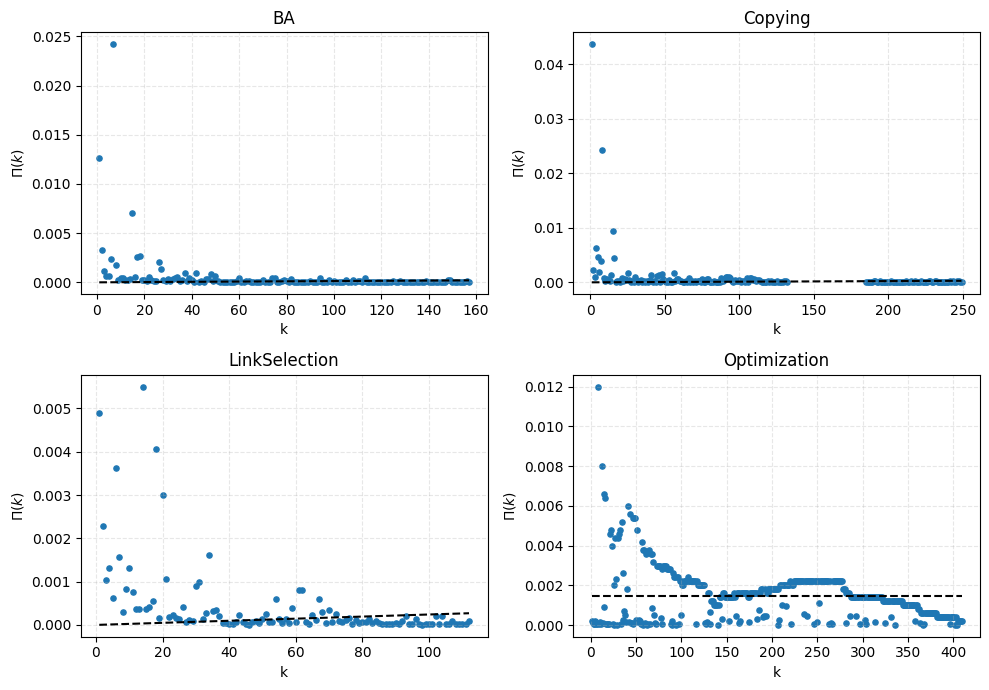

In [17]:
plot_pi_results_4panels(pi_res)

## Question 4

 I decided to use robustness to measure the distance between two graphs. Network robustness is characterized by the size of the largest connected component after removing target nodes. This metric directly reflects the network's ability to maintain global connectivity in the event of failures or attacks, which is crucial for the network's functional performance.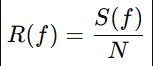Use the above formula to calculate the changes to the overall structure when random nodes are removed and then plot the results on a graph.

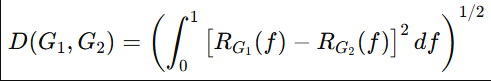

In the previous problem, we determined the specific function for achieving robustness. By comparing the numerical trends of G1 and G2, we can determine the differences between the two graphs. The specific steps are as follows: For each graph, progressively remove nodes in descending order of degree. After each removal fraction f, compute the size of the giant component. Normalize the curve by the original graph size. Compute the L2 distance between the two curves.

In [18]:
def robustness_curve(G: nx.Graph, num_points: int = 301, seed: int = 0):
    """
    Compute robustness curve R(f)=S(f)/N for a single graph G.

    Parameters
    ----------
    G : nx.Graph
        Input graph (undirected; directed graphs are treated as undirected).
    num_points : int
        Number of removal fractions f in [0,1].
    seed : int
        Random seed (used if attack="random").

    Returns
    -------
    f : np.ndarray
        Fractions of removed nodes.
    R : np.ndarray
        Robustness curve values R(f)=S(f)/N.
    """
    H = G.to_undirected().copy()
    num_N = H.number_of_nodes()
    if num_N == 0:
        raise ValueError("Graph has no nodes.")

    rng = np.random.default_rng(seed)
    nodes = list(H.nodes())
    order = list(nodes)
    rng.shuffle(order)

    f = np.linspace(0.0, 1.0, num_points)
    remove_counts = (f * num_N).round().astype(int)

    R = np.zeros_like(f, dtype=float)

    removed = 0
    for i, r in enumerate(remove_counts):
        if r > removed:
            H.remove_nodes_from(order[removed:r])
            removed = r

        if H.number_of_nodes() == 0:
            R[i] = 0.0
        else:
            giant = len(max(nx.connected_components(H), key=len))
            R[i] = giant / num_N

    return f, R


In [19]:

def robustness_distance(G1: nx.Graph, G2: nx.Graph, num_points: int = 301, seed: int = 0):
    """
    Compute L2 distance between robustness curves of G1 and G2.

    Returns
    -------
    dist : float
        L2 distance between R1(f) and R2(f).
    f : np.ndarray
        Fraction grid.
    R1, R2 : np.ndarray
        Robustness curves of G1 and G2.
    """
    f1, R1 = robustness_curve(G1, num_points, seed)
    f2, R2 = robustness_curve(G2, num_points, seed)

    if not np.allclose(f1, f2):
        f = np.linspace(0.0, 1.0, min(len(f1), len(f2)))
        R1 = np.interp(f, f1, R1)
        R2 = np.interp(f, f2, R2)
    else:
        f = f1

    df = f[1] - f[0] if len(f) > 1 else 1.0
    dist = np.sqrt(np.sum((R1 - R2) ** 2) * df)

    return dist


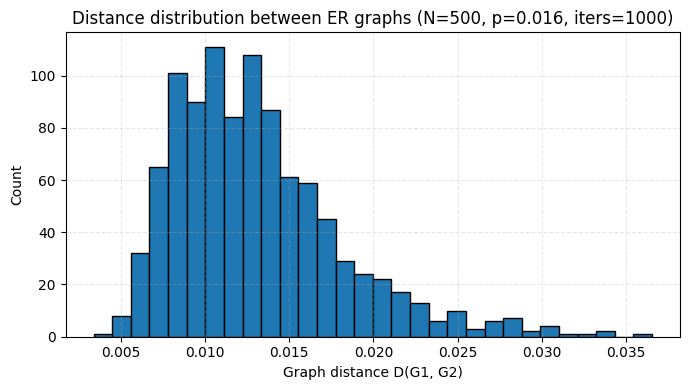

In [20]:
iters = 1000
N = 500
p = 0.016
seed = 3
rng = np.random.default_rng(3)
ER_dists = np.empty(iters, dtype=float)

for i in range(iters):
    # Different seeds so each ER draw is independent/reproducible
    s1 = int(rng.integers(0, 2**32 - 1))
    s2 = int(rng.integers(0, 2**32 - 1))

    G1 = nx.erdos_renyi_graph(N, p, seed=s1)
    G2 = nx.erdos_renyi_graph(N, p, seed=s2)

    dist = robustness_distance(G1, G2, num_points=301, seed=seed)
    ER_dists[i] = dist

# Plot distribution of distances
plt.figure(figsize=(7, 4))
plt.hist(ER_dists, bins=30, edgecolor="black")
plt.xlabel("Graph distance D(G1, G2)")
plt.ylabel("Count")
plt.title(f"Distance distribution between ER graphs (N={N}, p={p}, iters={iters})")
plt.grid(True, ls="--", alpha=0.3)
plt.tight_layout()
plt.show()

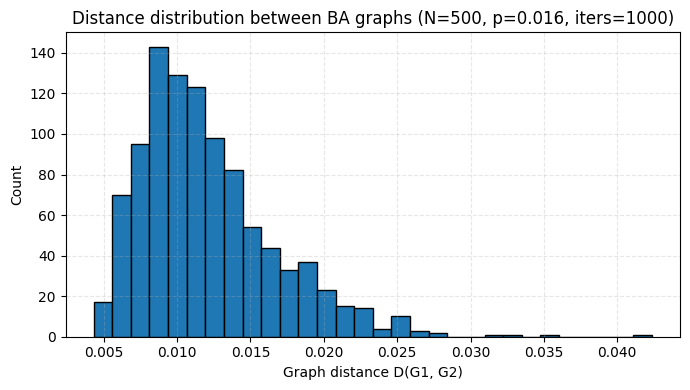

In [21]:
BA_dists = np.empty(iters, dtype=float)
for i in range(iters):
    # Different seeds so each ER draw is independent/reproducible
    s1 = int(rng.integers(0, 2**32 - 1))
    s2 = int(rng.integers(0, 2**32 - 1))

    G1 = nx.barabasi_albert_graph(N, m=4, seed=s1)
    G2 = nx.barabasi_albert_graph(N, m=4, seed=s2)

    dist = robustness_distance(G1, G2, num_points=301, seed=seed)
    BA_dists[i] = dist

# Plot distribution of distances
plt.figure(figsize=(7, 4))
plt.hist(BA_dists, bins=30, edgecolor="black")
plt.xlabel("Graph distance D(G1, G2)")
plt.ylabel("Count")
plt.title(f"Distance distribution between BA graphs (N={N}, p={p}, iters={iters})")
plt.grid(True, ls="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
MIX_dists = np.empty(iters, dtype=float)
for i in range(iters):
    # Different seeds so each ER draw is independent/reproducible
    s1 = int(rng.integers(0, 2**32 - 1))
    s2 = int(rng.integers(0, 2**32 - 1))

    G1 = nx.barabasi_albert_graph(N, m=4, seed=s1)
    G2 = nx.erdos_renyi_graph(N, p, seed=s2)

    dist = robustness_distance(G1, G2, num_points=301, seed=seed)
    MIX_dists[i] = dist


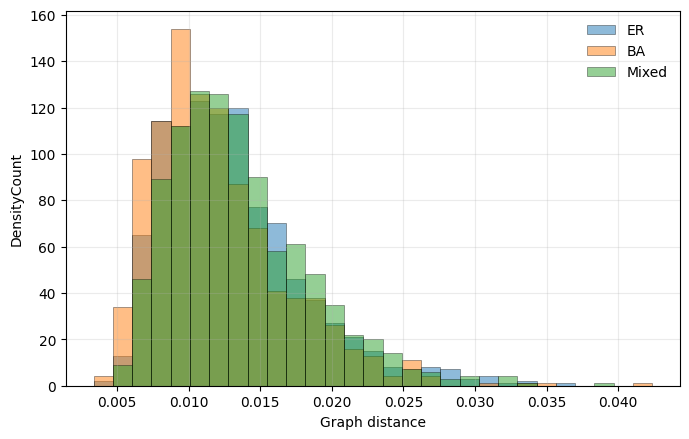

In [22]:
    
xmin = min(ER_dists.min(), BA_dists.min(), MIX_dists.min())
xmax = max(ER_dists.max(), BA_dists.max(), MIX_dists.max())
bins = np.linspace(xmin, xmax, 30)

plt.figure(figsize=(7, 4.5))

plt.hist(
    ER_dists, bins=bins,
    alpha=0.5, label="ER",
    color="#1f77b4", edgecolor="black", linewidth=0.5
)
plt.hist(
    BA_dists, bins=bins,
    alpha=0.5, label="BA",
    color="#ff7f0e", edgecolor="black", linewidth=0.5
)
plt.hist(
    MIX_dists, bins=bins,
    alpha=0.5, label="Mixed",
    color="#2ca02c", edgecolor="black", linewidth=0.5
)

plt.xlabel("Graph distance")
plt.ylabel("DensityCount")
plt.legend(frameon=False)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Robustness is a quantitative measure of a network’s ability to maintain global connectivity under node or edge removal.
In Erdős–Rényi (ER) graphs, edges are distributed uniformly at random, so the removal of nodes or edges typically affects the network in a homogeneous way and does not immediately fragment the giant connected component.
In Barabási–Albert (BA) graphs, overall connectivity is dominated by a small number of high-degree hub nodes. However, under random removal, the probability of selecting such hub nodes is low, so the network remains largely connected for most realizations.
As a result, ER and BA graphs exhibit similar robustness behavior under random failures, leading to overlapping and similarly shaped robustness-based distance distributions, as observed in the figure.

## Question 5

In [22]:
def gen_graphs(seed = seed):
    N = 5000
    p = 10 / (N - 1)
    m = 10 // 2
    d = 10
    ER_graph = nx.erdos_renyi_graph(N, p, seed=seed)
    BA_graph = nx.barabasi_albert_graph(N, m, seed=seed)
    RR_graph = nx.random_regular_graph(d, N, seed=seed)
    return ER_graph, BA_graph,RR_graph
def gcc_fractiosn(G):
    """Return |GCC| / N for an undirected graph."""
    n = G.number_of_nodes()
    if n == 0:
        return 0.0
    largest = max((len(c) for c in nx.connected_components(G)), default=0)
    return largest / n

def simulate_node_removal(G, f_list, strategy="random", seed=0):
    """
    Simulate node removal on a copy of G.

    Parameters
    ----------
    G : nx.Graph
    f_list : iterable of floats
        Fractions to remove, e.g. [0.00, 0.02, ..., 0.40]
    strategy : {"random", "targeted"}
    seed : int

    Returns
    -------
    S : np.ndarray
        GCC fraction after removal at each f in f_list, same order.
    """
    rng = np.random.default_rng(seed)

    H = G.copy()
    num_N = H.number_of_nodes()
    f_list = np.asarray(list(f_list), dtype=float)

    nodes = np.array(list(H.nodes()))
    if strategy == "random":
        removal_order = rng.permutation(nodes)
    elif strategy == "targeted":
        deg = dict(G.degree())
        removal_order = sorted(G.nodes(), key=lambda u: deg[u], reverse=True)
        removal_order = np.array(removal_order)

    S = np.zeros_like(f_list, dtype=float)
    removed = 0

    for i, f in enumerate(f_list):
        target_removed = int(np.floor(f * num_N))
        if target_removed > removed:
            to_remove = removal_order[removed:target_removed]
            H.remove_nodes_from(to_remove)
            removed = target_removed

        if H.number_of_nodes() == 0:
            S[i] = 0.0
        else:
            largest = max((len(c) for c in nx.connected_components(H)), default=0)
            S[i] = largest / num_N

    return S

In [23]:
def run_all_simulations(seed=0, n_realizations=10, f_max=0.40, step=0.02, plot=True):
    f_list = np.round(np.arange(0.0, f_max + 1e-12, step), 2)

    # store arrays shape: (n_realizations, len(f_list))
    out = {
        "f": f_list,
        "ER_random": [],
        "ER_targeted": [],
        "BA_random": [],
        "BA_targeted": [],
        "RR_random": [],
        "RR_targeted": [],
    }

    for r in range(n_realizations):
        # different graph realization each time
        g_seed = seed + 10 * r
        ER, BA, RR = gen_graphs(seed=g_seed)

        # different removal RNG each time (especially matters for random failure)
        rem_seed = seed + 9 * r

        out["ER_random"].append(simulate_node_removal(ER, f_list, "random",   seed=rem_seed + 1))
        out["ER_targeted"].append(simulate_node_removal(ER, f_list, "targeted", seed=rem_seed + 2))

        out["BA_random"].append(simulate_node_removal(BA, f_list, "random",   seed=rem_seed + 3))
        out["BA_targeted"].append(simulate_node_removal(BA, f_list, "targeted", seed=rem_seed + 4))

        out["RR_random"].append(simulate_node_removal(RR, f_list, "random",   seed=rem_seed + 5))
        out["RR_targeted"].append(simulate_node_removal(RR, f_list, "targeted", seed=rem_seed + 6))

    # convert lists -> arrays
    for k in list(out.keys()):
        if k != "f":
            out[k] = np.vstack(out[k])  # (R, F)

    # compute mean/std
    stats = {"f": f_list}
    for name in ["ER", "BA", "RR"]:
        for strat in ["random", "targeted"]:
            key = f"{name}_{strat}"
            stats[f"{key}_mean"] = out[key].mean(axis=0)
            stats[f"{key}_std"]  = out[key].std(axis=0, ddof=1) if n_realizations > 1 else np.zeros_like(f_list)

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
        ensembles = [("ER", "Erdős–Rényi"), ("BA", "Barabási–Albert"), ("RR", "Random Regular")]

        for ax, (name, title) in zip(axes, ensembles):
            mu_r = stats[f"{name}_random_mean"]
            sd_r = stats[f"{name}_random_std"]
            mu_t = stats[f"{name}_targeted_mean"]
            sd_t = stats[f"{name}_targeted_std"]

            # random failure curve + band
            ax.plot(f_list, mu_r, label="Random failure")
            ax.fill_between(f_list, mu_r - sd_r, mu_r + sd_r, alpha=0.2)

            # targeted attack curve + band
            ax.plot(f_list, mu_t, label="Targeted attack")
            ax.fill_between(f_list, mu_t - sd_t, mu_t + sd_t, alpha=0.2)

            ax.set_title(title)
            ax.set_xlabel("f")
            ax.grid(alpha=0.25)
            ax.set_xlim(f_list.min(), f_list.max())
            ax.set_ylim(0, 1.02)

        axes[0].set_ylabel("S(f)")
        axes[-1].legend(loc="upper right", frameon=False)
        plt.tight_layout()
        plt.show()

    return stats, out


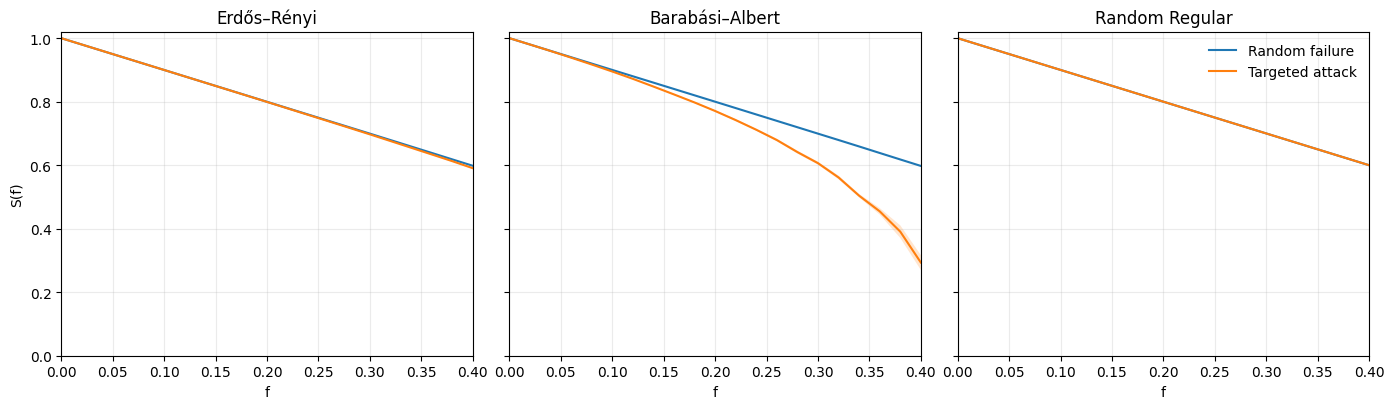

In [24]:
stats, raw = run_all_simulations(seed=5, n_realizations=10, plot=True)